# ASE databases: structures, metadata, and adsorption screening

This notebook follows the [ASE database documentation](https://ase-lib.org/ase/db/db.html). The first part introduces command-line and Python workflows for storing, selecting, relaxing, and updating atomic structures. The second part builds an adsorption-screening dataset that separates bulk, adsorbate-covered slab, and reference calculations into related databases. The final sections audit and visualize all 63 adsorption rows, export selected results, store database-level provenance, test model sensitivity, and provide an opt-in GPAW validation workflow.

An ASE database row can contain an atomic structure, calculator results such as energy and forces, queryable key-value pairs, and an auxiliary `data` dictionary. Keeping those categories distinct is central to making the database searchable and reproducible.

Unless stated otherwise, distances are in ångström (Å), energies are in electronvolts (eV), forces are in eV/Å, and bulk moduli returned by the EOS fit are in eV/Å³.

## Creating structures from the command line

The `ase build` commands construct primitive periodic FCC cells for Al, Cu, and Au. In an interactive terminal, omitting the output filename writes `Al.json`, `Cu.json`, or `Au.json` in the current directory.

```bash
ase build -x fcc Al
ase build -x fcc Cu
ase build -x fcc Au
```

### Converting structure files into a database

`ase convert` reads the three JSON structures and writes them as separate rows in a SQLite database. The filename suffix selects the output format. This command assumes that the terminal is in the directory containing the JSON files.

```bash
ase convert Al.json Cu.json Au.json database.db
```

The Python workflow below creates the same three structures directly and stores them in `../files/advanced/tutorial_05/database.db`. It first deletes any database at that path, so rerunning the cell intentionally replaces the tutorial database rather than appending to it.

In [1]:
from pathlib import Path

from ase.build import bulk
from ase.calculators.emt import EMT
from ase.db import connect
from ase.filters import FrechetCellFilter
from ase.optimize import BFGS

dbfile = Path('../files/advanced/tutorial_05/database.db')
dbfile.unlink(missing_ok=True)

structures = ['Al', 'Cu', 'Au']
db = connect(dbfile)

for structure in structures:
    db.write(bulk(structure))

### Visualizing the source structures

The plot reconstructs each bulk structure from its chemical symbol rather than reading it back from the database. Multiplication by `3` repeats the one-atom FCC primitive cell three times along every lattice direction, producing a 27-atom visualization. The rotation and `show_unit_cell=0` setting affect only the drawing.

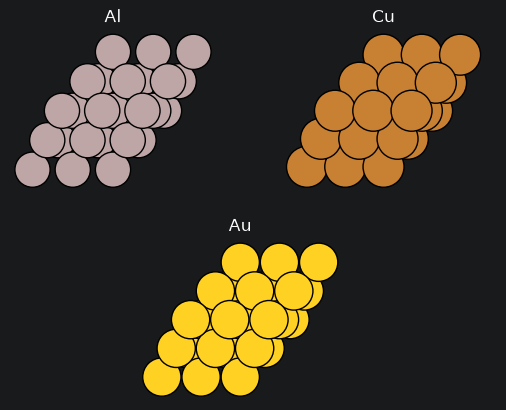

In [2]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

from ase.visualize.plot import plot_atoms

fig = plt.figure()
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])

# Hide unused bottom-right cell
ax_unused = fig.add_subplot(gs[1, 1])
ax_unused.axis('off')

# --- Center bottom axis manually ---
pos1 = ax1.get_position()
pos3 = ax3.get_position()
new_x0 = 0.5 - pos3.width / 2
ax3.set_position([new_x0, pos3.y0, pos3.width, pos3.height])

for name, ax in zip(structures, [ax1, ax2, ax3]):
    plot_atoms(bulk(name) * 3, ax, rotation='0x,30y,0z', show_unit_cell=0)
    ax.set_title(name)
    ax.set_axis_off()

## Querying a database from the command line

With no selection expression, `ase db` lists the database rows and a default set of columns such as row ID, formula, calculator, energy, atom count, and periodic-boundary flags.

```bash
ase db database.db
```

### Filtering rows

A chemical symbol can be used as a selection expression. This command restricts the listing to rows containing Al; more general selections can combine IDs, formulas, calculator fields, and user-defined key-value pairs.

```bash
ase db database.db Al
```

### Opening database rows in the ASE GUI

The GUI can browse the stored structures as a collection. It launches a separate desktop process and requires a working graphical Python installation, including Tk on the current macOS setup. If `_tkinter` is unavailable, notebook-native `plot_atoms` visualizations remain usable.

```bash
ase gui database.db
```

### Applying a selection when opening the GUI

The `database@selection` syntax passes only matching rows to the viewer. Here, the GUI receives the Al-containing subset rather than the full database.

```bash
ase gui database.db@Al
```

## Reading database rows with Python

`connect(dbfile)` opens the backend inferred from the `.db` suffix. `db.select()` iterates over matching `AtomsRow` records, while `row.toatoms()` reconstructs an `Atoms` object containing the symbols, cell, positions, and periodicity. Calculator results and user metadata remain available on the row and can also be restored when needed.

The printed objects confirm that the initial database contains three one-atom periodic FCC primitive cells.

In [3]:
db = connect(dbfile)
for row in db.select():
    atoms = row.toatoms()
    print(atoms)

Atoms(symbols='Al', pbc=True, cell=[[0.0, 2.025, 2.025], [2.025, 0.0, 2.025], [2.025, 2.025, 0.0]])
Atoms(symbols='Cu', pbc=True, cell=[[0.0, 1.805, 1.805], [1.805, 0.0, 1.805], [1.805, 1.805, 0.0]])
Atoms(symbols='Au', pbc=True, cell=[[0.0, 2.04, 2.04], [2.04, 0.0, 2.04], [2.04, 2.04, 0.0]])


## Relaxing structures and writing derived rows

Each original structure is reconstructed, assigned an EMT calculator, and passed through `FrechetCellFilter`, which exposes both atomic and cell degrees of freedom to BFGS. The explicit stress request initializes the relevant calculator results before optimization.

The filter run stops when its largest generalized force is below `fmax=0.05`. For a cell filter, this criterion combines atomic and cell-related components and should not be interpreted directly as a stress tolerance of $0.05$ eV/Å³.

The optimized structures are appended as new rows with the queryable key-value pair `relaxed=True`; the three source rows remain, so the database now has six rows. Because the attached calculator has evaluated the final structure, ASE also stores its energy and other available results with each relaxed row.

In [4]:
for row in db.select():
    atoms = row.toatoms()
    calc = EMT()
    atoms.calc = calc
    atoms.get_stress()
    filter = FrechetCellFilter(atoms)
    opt = BFGS(filter)
    opt.run(fmax=0.05)
    db.write(atoms=atoms, relaxed=True)

      Step     Time          Energy          fmax
BFGS:    0 12:37:13       -0.001502        0.161794
BFGS:    1 12:37:13       -0.002532        0.135189
BFGS:    2 12:37:13       -0.004882        0.002382
      Step     Time          Energy          fmax
BFGS:    0 12:37:13       -0.005682        0.160183
BFGS:    1 12:37:13       -0.006560        0.095504
BFGS:    2 12:37:13       -0.007036        0.001838
      Step     Time          Energy          fmax
BFGS:    0 12:37:13        0.002606        0.308859
BFGS:    1 12:37:13        0.000034        0.077987
BFGS:    2 12:37:13       -0.000135        0.002381


## Updating existing rows with auxiliary data

ASE distinguishes several kinds of row content:

- calculator properties such as `energy`, stored automatically when available;
- key-value pairs such as `relaxed=True`, which can be selected and displayed as database columns;
- the auxiliary `data` dictionary, intended for additional JSON-compatible content that is not a normal query key.

The cell below selects only relaxed rows, recalculates their EMT energies, and stores each value in `row.data['energy']`. In this notebook that number duplicates the built-in calculator energy already present on the row, but the example demonstrates how `db.update()` can attach structured auxiliary information without rewriting the atomic structure.

In [5]:
for row in db.select(relaxed=True):
    atoms = row.toatoms()
    calc = EMT()
    atoms.calc = calc
    e = atoms.get_potential_energy()
    db.update(row.id, data={'energy': e})

### Inspecting all database columns

`-c++` requests all standard and queryable key-value columns. It reveals the `relaxed` tag and calculator-derived energy for the three optimized rows; auxiliary `data` remains accessible through Python rather than becoming a query column.

```bash
ase db database.db -c++
```

## Surface adsorption screening study

The remainder of the notebook uses databases as a lightweight workflow manager. It considers seven FCC metals (`Al`, `Ni`, `Cu`, `Pd`, `Ag`, `Pt`, and `Au`), three adsorbates (`C`, `N`, and `O`), and slabs containing one, two, or three layers. The full Cartesian product contains $7 \times 3 \times 3 = 63$ adsorbate-covered structures.

Three databases separate different calculation roles: `bulk.db` stores equilibrium bulk structures, `ads.db` stores adsorbate-covered slabs, and `refs.db` stores clean slabs and isolated adsorbate atoms. All calculations use EMT, so this is a database and screening demonstration rather than a quantitatively converged adsorption study.

### Building the equilibrium bulk database

For each metal, `calculate_eos` evaluates a small volume series and fits the equilibrium volume $V_0$, minimum energy, and bulk modulus $B$. The cell is rescaled to $V_0$, evaluated once more, and written with the queryable key `bm=B`.

For ASE's FCC primitive-cell orientation, the later expression for the conventional lattice constant is

$$
a = 2 \times \mathrm{cell}[0, 1].
$$

This indexing rule is specific to that cell representation. The fitted bulk modulus is stored in eV/Å³; multiplication by $160.2177$ converts it to GPa. As in the earlier example, the existing `bulk.db` is deleted before rebuilding it.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt

from ase import Atoms
from ase.build import add_adsorbate, bulk, fcc111
from ase.calculators.emt import EMT
from ase.constraints import FixAtoms
from ase.db import connect
from ase.eos import calculate_eos
from ase.io import write
from ase.optimize import BFGS
from ase.visualize.plot import plot_atoms


bulk_syms = ['Al', 'Ni', 'Cu', 'Pd', 'Ag', 'Pt', 'Au']
path_to_bulk_db = Path('../files/advanced/tutorial_05/bulk.db')

# clean up if there is an old file
path_to_bulk_db.unlink(missing_ok=True)
# use context manage to ensure that connection is closed afterwards
with connect(path_to_bulk_db) as bulk_db:
    for symb in bulk_syms:
        atoms = bulk(symb, 'fcc')

        atoms.calc = EMT()
        eos = calculate_eos(atoms)
        v, e, B = eos.fit()  # find minimum
        # do one more calculation at the minimum and write to database:
        atoms.cell *= (v / atoms.get_volume()) ** (1 / 3)
        atoms.get_potential_energy()
        bulk_db.write(atoms, bm=B)

### Displaying the fitted bulk modulus

The `-c +bm` option adds the user-defined `bm` field to the usual database columns. Run the command from the directory containing `bulk.db`, or supply its full path.

```bash
ase db bulk.db -c +bm
```

### Inspecting the final bulk structure

After the loop, `atoms` still refers to its final value: the equilibrium Au structure. The plot therefore checks that single structure rather than visualizing all seven database rows. Reading rows back from `bulk.db` would be the database-centered way to make a complete comparison.

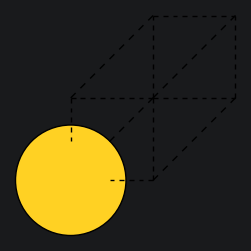

In [7]:
fig, ax = plt.subplots(figsize=(3, 3))
plot_atoms(atoms, ax)
ax.set_axis_off()

## Generating and reserving adsorbate calculations

`optimize_adsorbate` builds a $(1 \times 1)$ FCC(111) slab, places the adsorbate $1.0$ Å above an FCC hollow site, freezes every substrate atom, and relaxes only the adsorbate to `fmax=0.01` eV/Å with EMT. Varying `nlayer` changes the slab thickness, but the frozen substrate cannot reconstruct in response to adsorption.

The nested loops generate 63 combinations. Each database row is labeled by the queryable keys `surf`, `ads`, and `layers`. `reserve()` first claims a unique combination and returns a row ID; a `None` return indicates that another row already has those keys. This pattern is useful when multiple workers share a database, although the present serial workflow recreates an empty database before starting.

> The lattice-constant extraction `row.cell[0, 1] * 2` relies on the FCC primitive-cell convention used above and is not a general lattice-constant formula.

In [8]:
path_to_ads_db = Path('../files/advanced/tutorial_05/ads.db')
ads_syms = ['C', 'N', 'O']
nlayers = [1, 2, 3]


def optimize_adsorbate(symb, alat, nlayer, ads):
    atoms = fcc111(symb, (1, 1, nlayer), a=alat)
    add_adsorbate(atoms, ads, height=1.0, position='fcc')

    # Constrain all atoms except the adsorbate:
    fixed = list(range(len(atoms) - 1))
    atoms.constraints = [FixAtoms(indices=fixed)]

    atoms.calc = EMT()
    opt = BFGS(atoms, logfile=None)
    opt.run(fmax=0.01)
    return atoms


# clean up if there is an old file
path_to_ads_db.unlink(missing_ok=True)
# again use context-manager
with connect(path_to_ads_db) as ads_db:
    for row in bulk_db.select():
        alat = row.cell[0, 1] * 2  # lattice constant
        symb = row.symbols[0]
        for nlayer in nlayers:
            for ads in ads_syms:
                atoms = optimize_adsorbate(symb, alat, nlayer, ads)
                myid = ads_db.reserve(layers=nlayer, surf=symb, ads=ads)
                if myid is not None:
                    ads_db.write(
                        atoms, id=myid, layers=nlayer, surf=symb, ads=ads
                    )

### Querying and visualizing selected structures

`ads_db.get(surf='Cu', ads='O', layers=nlayer)` expects exactly one matching row for each layer count. Converting that row with `toatoms()` restores the corresponding structure. Repeating it by $(4, 4, 1)$ makes the periodic surface easier to recognize, but the replicated object is used only for plotting and does not alter any stored calculation.

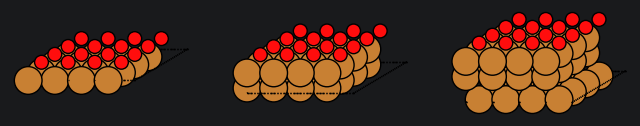

In [9]:
fig, axes = plt.subplots(ncols=3, figsize=(8, 2))
with connect(path_to_ads_db) as ads_db:
    for i, nlayer in enumerate(nlayers):
        atoms = ads_db.get(surf='Cu', ads='O', layers=nlayer).toatoms()
        atoms_sc = atoms * (4, 4, 1)
        plot_atoms(atoms_sc, axes[i], rotation='-70x,0y,0z')
        axes[i].set_axis_off()

## Constructing reference-energy rows

Adsorption energies require clean-surface and isolated-atom references evaluated with the same calculator. `refs.db` therefore contains $7 \times 3 = 21$ clean slabs plus three isolated atoms, for 24 rows in total.

`clean_surface_reference` builds the ideal slab and requests its forces to trigger EMT, but it does not optimize the clean surface. The adsorbate-covered calculation likewise keeps the substrate fixed while relaxing only the adsorbate. The isolated C, N, and O atoms are evaluated as separate non-periodic `Atoms` objects.

Using consistent EMT references makes the subtraction internally defined, but an isolated-atom reference is not interchangeable with molecular or experimental reference states such as $\mathrm{O}_2$.

In [10]:
path_to_refs_db = Path('../files/advanced/tutorial_05/refs.db')


def clean_surface_reference(symb, alat, nlayer):
    atoms = fcc111(symb, (1, 1, nlayer), a=alat)
    atoms.calc = EMT()
    atoms.get_forces()
    return atoms


# clean slabs
path_to_refs_db.unlink(missing_ok=True)
# connect to refs_db for writing
with connect(path_to_refs_db) as refs_db:
    # connect bulk_db for reading
    with connect(path_to_bulk_db) as bulk_db:
        for row in bulk_db.select():
            alat = row.cell[0, 1] * 2  # lattice constant
            symb = row.symbols[0]
            for nlayer in nlayers:
                myid = refs_db.reserve(layers=nlayer, surf=symb, ads='clean')
                if myid is not None:
                    atoms = clean_surface_reference(symb, alat, nlayer)
                    refs_db.write(
                        atoms, id=myid, layers=nlayer, surf=symb, ads='clean'
                    )

    # isolated atoms:
    for ads in ads_syms:
        atoms = Atoms(ads)
        atoms.calc = EMT()
        atoms.get_potential_energy()
        myid = refs_db.reserve(ads=ads)
        if myid is not None:
            refs_db.write(atoms, id=myid, ads=ads)

## Calculating adsorption energies and heights

For every adsorbate-covered row, the adsorption energy is calculated as

$$
E_{\mathrm{ads}} = E_{\mathrm{slab+adsorbate}} - E_{\mathrm{clean\ slab}} - E_{\mathrm{isolated\ atom}}.
$$

With this convention, a negative value means that the combined adsorbate-slab system is lower in energy than the separated clean slab and isolated atom. The result is saved as the queryable key `ea`.

The stored `height` is the $z$-coordinate difference between the final atom (the adsorbate) and the preceding substrate atom. This is a vertical height for the current atom ordering and surface orientation, not a general nearest-neighbor bond length. Both `ea` and `height` are added as key-value pairs so they can be filtered, sorted, plotted, or exported directly from the database.

In [11]:
# connect to ads_db for updating
with connect(path_to_ads_db) as ads_db:
    # connect to refs_db for reading
    with connect(path_to_refs_db) as refs_db:
        for row in ads_db.select():
            # atoms
            e_ads = refs_db.get(formula=row.ads).energy
            # clean surface
            e_clean = refs_db.get(
                surf=row.surf, layers=row.layers, ads='clean'
            ).energy
            ea = row.energy - e_ads - e_clean
            h = row.positions[-1, 2] - row.positions[-2, 2]
            ads_db.update(row.id, ea=ea, height=h)

### Interpreting the Cu–O layer series

The current `ads.db` contains the following values for the structures plotted above:

| Cu layers | $E_{\mathrm{ads}}$ (eV) | Height (Å) |
| ---: | ---: | ---: |
| 1 | -4.6605 | 1.5806 |
| 2 | -4.6426 | 1.5865 |
| 3 | -4.6425 | 1.5865 |

The two- and three-layer results differ by less than $0.0001$ eV in adsorption energy and have nearly identical heights, whereas the one-layer result differs by about $0.018$ eV. This suggests apparent layer convergence within this particular frozen, $(1 \times 1)$ EMT model. It does not establish convergence with respect to lateral cell size, substrate relaxation, adsorption site, vacuum, or electronic-structure method.

## Rendering selected rows with POV-Ray

ASE's POV writer creates a `.pov` scene and an associated `.ini` file, then returns a renderer object. `renderer.render()` launches the external `povray` executable to create a PNG, so POV-Ray must be installed and available on `PATH`; writing the scene alone does not require the executable.

The absolute database path remains valid while `chdir(output_dir)` makes the generated `.ini`, `.pov`, and `.png` paths resolve together inside the tutorial output directory. Passing `stderr=None` exposes POV-Ray's parser and rendering messages in the notebook. The three repeated Cu–O structures are presentation copies only and are not written back to `ads.db`.

In [12]:
from contextlib import chdir
from pathlib import Path

output_dir = Path('../files/advanced/tutorial_05').resolve()

with connect(path_to_ads_db.resolve()) as ads_db:
    for nlayer in nlayers:
        atoms = ads_db.get(
            surf='Cu',
            ads='O',
            layers=nlayer,
        ).toatoms()

        atoms_sc = atoms * (4, 4, 1)

        with chdir(output_dir):
            renderer = write(
                f'Cu{nlayer}O.pov',
                atoms_sc,
                rotation='-80x',
            )
            renderer.render(stderr=None)

Persistence of Vision(tm) Ray Tracer Version 3.7.0.10.unofficial (clang++ 17.0.0
 @ aarch64-apple-darwin25.2.0)
This is an unofficial version compiled by:
 Homebrew
 The POV-Ray Team is not responsible for supporting this version.

POV-Ray is based on DKBTrace 2.12 by David K. Buck & Aaron A. Collins
Copyright 1991-2013 Persistence of Vision Raytracer Pty. Ltd.

Primary POV-Ray 3.7 Architects/Developers: (Alphabetically)
  Chris Cason         Thorsten Froehlich  Christoph Lipka   

With Assistance From: (Alphabetically)
  Ton van den Broek   Nicolas Calimet     Jerome Grimbert     James Holsenback  
  Christoph Hormann   Nathan Kopp         Juha Nieminen     

Past Contributors: (Alphabetically)
  Steve Anger         Eric Barish         Dieter Bayer        David K. Buck     
  Nicolas Calimet     Chris Cason         Aaron A. Collins    Chris Dailey      
  Steve Demlow        Andreas Dilger      Alexander Enzmann   Dan Farmer        
  Thorsten Froehlich  Mark Gordon         James Hols

## Auditing all 63 adsorption rows

Before comparing adsorption energies, the database should be checked against the intended Cartesian product of seven surfaces, three adsorbates, and three slab thicknesses. The audit below detects missing combinations, unexpected combinations, duplicate keys, and rows lacking `energy`, `ea`, or `height`. It raises an error instead of allowing an incomplete grid to produce a plausible-looking plot.

The validated rows are converted into `adsorption_records`, a list of plain dictionaries sorted by slab thickness, surface order, and adsorbate order. This representation separates database validation from plotting and export while retaining the row ID needed to recover each full structure.

In [13]:
from collections import Counter

expected_keys = {
    (surface, adsorbate, layers)
    for surface in bulk_syms
    for adsorbate in ads_syms
    for layers in nlayers
}

with connect(path_to_ads_db) as ads_db:
    adsorption_rows = list(ads_db.select())

observed_keys = [
    (row.surf, row.ads, row.layers) for row in adsorption_rows
]
key_counts = Counter(observed_keys)
missing_keys = sorted(expected_keys - set(observed_keys))
unexpected_keys = sorted(set(observed_keys) - expected_keys)
duplicate_keys = sorted(
    key for key, count in key_counts.items() if count > 1
)
incomplete_rows = sorted(
    row.id
    for row in adsorption_rows
    if any(
        getattr(row, field, None) is None
        for field in ('energy', 'ea', 'height')
    )
)

audit_problems = {
    'missing': missing_keys,
    'unexpected': unexpected_keys,
    'duplicates': duplicate_keys,
    'incomplete_row_ids': incomplete_rows,
}
if any(audit_problems.values()):
    raise RuntimeError(f'Adsorption database audit failed: {audit_problems}')

surface_order = {symbol: index for index, symbol in enumerate(bulk_syms)}
adsorbate_order = {symbol: index for index, symbol in enumerate(ads_syms)}
adsorption_records = [
    {
        'row_id': row.id,
        'surface': row.surf,
        'adsorbate': row.ads,
        'layers': row.layers,
        'total_energy_eV': row.energy,
        'adsorption_energy_eV': row.ea,
        'height_A': row.height,
    }
    for row in sorted(
        adsorption_rows,
        key=lambda row: (
            row.layers,
            surface_order[row.surf],
            adsorbate_order[row.ads],
        ),
    )
]

print(f'Validated {len(adsorption_records)} unique adsorption rows.')
print('Expected grid: 7 surfaces × 3 adsorbates × 3 slab thicknesses.')

Validated 63 unique adsorption rows.
Expected grid: 7 surfaces × 3 adsorbates × 3 slab thicknesses.


## Metal–adsorbate energy heatmaps

Each panel contains one slab thickness. Rows are adsorbates, columns are metal surfaces, and every cell shows $E_{\mathrm{ads}}$ in eV using the isolated-atom convention defined above. All panels share one color scale, so changes across slab thickness can be compared without rescaling the colors.

The accompanying layer check evaluates $|E_{\mathrm{ads}}^{(3)} - E_{\mathrm{ads}}^{(2)}|$ for all 21 metal–adsorbate pairs. The threshold of $0.01$ eV is a named screening tolerance, not a universal accuracy standard. In this EMT dataset, all 21 pairs pass that screen; the largest signed three-minus-two-layer change is $+0.000222$ eV for Pt–N.

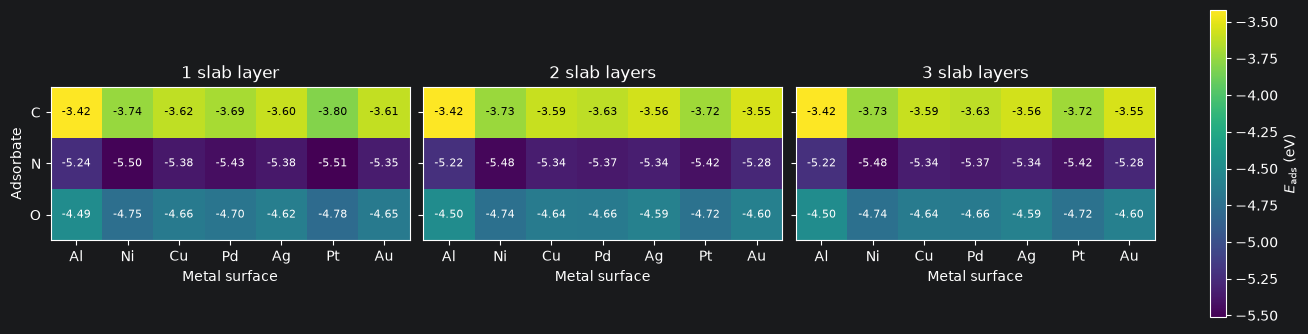

21/21 pairs satisfy |E(3 layers) - E(2 layers)| < 0.01 eV.
Largest 3-minus-2-layer change: Pt-N (+0.000222 eV).


In [14]:
import numpy as np

energy_lookup = {
    (record['surface'], record['adsorbate'], record['layers']):
        record['adsorption_energy_eV']
    for record in adsorption_records
}
energy_limits = [
    record['adsorption_energy_eV'] for record in adsorption_records
]
vmin, vmax = min(energy_limits), max(energy_limits)

fig, axes = plt.subplots(
    ncols=len(nlayers), figsize=(13, 3.5), sharey=True,
    constrained_layout=True,
)
for ax, layers in zip(axes, nlayers):
    matrix = np.array([
        [
            energy_lookup[(surface, adsorbate, layers)]
            for surface in bulk_syms
        ]
        for adsorbate in ads_syms
    ])
    image = ax.imshow(matrix, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(bulk_syms)), bulk_syms)
    ax.set_yticks(range(len(ads_syms)), ads_syms)
    ax.set_xlabel('Metal surface')
    ax.set_title(f'{layers} slab layer' + ('s' if layers > 1 else ''))

    color_midpoint = 0.5 * (vmin + vmax)
    for ads_index in range(len(ads_syms)):
        for surface_index in range(len(bulk_syms)):
            value = matrix[ads_index, surface_index]
            text_color = 'white' if value < color_midpoint else 'black'
            ax.text(
                surface_index,
                ads_index,
                f'{value:.2f}',
                ha='center',
                va='center',
                color=text_color,
                fontsize=8,
            )

axes[0].set_ylabel('Adsorbate')
fig.colorbar(
    image, ax=axes, label=r'$E_{\mathrm{ads}}$ (eV)', shrink=0.9
)
plt.show()

layer_screening_tolerance = 0.01  # eV
layer_differences = [
    {
        'surface': surface,
        'adsorbate': adsorbate,
        'delta_3_minus_2_eV': (
            energy_lookup[(surface, adsorbate, 3)]
            - energy_lookup[(surface, adsorbate, 2)]
        ),
    }
    for surface in bulk_syms
    for adsorbate in ads_syms
]
largest_layer_change = max(
    layer_differences,
    key=lambda result: abs(result['delta_3_minus_2_eV']),
)
n_layer_converged = sum(
    abs(result['delta_3_minus_2_eV']) < layer_screening_tolerance
    for result in layer_differences
)
print(
    f'{n_layer_converged}/{len(layer_differences)} pairs satisfy '
    f'|E(3 layers) - E(2 layers)| < {layer_screening_tolerance:.2f} eV.'
)
print(
    'Largest 3-minus-2-layer change: '
    f"{largest_layer_change['surface']}-{largest_layer_change['adsorbate']} "
    f"({largest_layer_change['delta_3_minus_2_eV']:+.6f} eV)."
)

## CSV export and database-level provenance

The CSV export contains selected scalar results and the ASE row ID. It is convenient for external plotting or review, while `ads.db` remains the source of truth for structures, calculator results, and queryable metadata. Energies remain in eV and heights in Å, with units encoded in the column names.

ASE databases also support a database-level `metadata` dictionary. The cell records the ASE and Python versions, calculator identity and parameters, generation time, and workflow-specific settings for `bulk.db`, `ads.db`, and `refs.db`. These settings describe the database as a whole; parameters that vary between rows should instead be stored as row-level keys.

In [15]:
import csv
import platform
from datetime import datetime, timezone

import ase

output_dir = Path('../files/advanced/tutorial_05')
output_dir.mkdir(parents=True, exist_ok=True)
csv_path = output_dir / 'adsorption_summary.csv'
csv_columns = [
    'row_id',
    'surface',
    'adsorbate',
    'layers',
    'total_energy_eV',
    'adsorption_energy_eV',
    'height_A',
]
with csv_path.open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=csv_columns)
    writer.writeheader()
    writer.writerows(adsorption_records)

generated_utc = datetime.now(timezone.utc).isoformat()
environment_metadata = {
    'schema_version': 1,
    'generated_utc': generated_utc,
    'ase_version': ase.__version__,
    'python_version': platform.python_version(),
    'calculator': 'ase.calculators.emt.EMT',
    'calculator_parameters': EMT().todict(),
}
database_settings = {
    path_to_bulk_db: {
        'workflow': 'fcc equation of state',
        'elements': bulk_syms,
        'eos_points': 5,
        'eos_fractional_strain': 0.04,
    },
    path_to_ads_db: {
        'workflow': 'adsorbate-covered fcc(111) slabs',
        'surfaces': bulk_syms,
        'adsorbates': ads_syms,
        'layers': nlayers,
        'lateral_size': [1, 1],
        'adsorption_site': 'fcc',
        'initial_adsorbate_height_A': 1.0,
        'optimizer': 'BFGS',
        'fmax_eV_per_A': 0.01,
        'substrate_constraint': 'all substrate atoms fixed',
    },
    path_to_refs_db: {
        'workflow': 'clean-slab and isolated-atom references',
        'clean_slab_optimization': 'single-point EMT',
        'adsorbate_reference': 'isolated atom',
        'adsorption_energy_definition': (
            'E(slab+adsorbate) - E(clean slab) - E(isolated atom)'
        ),
    },
}
for database_path, settings in database_settings.items():
    with connect(database_path) as database:
        database.metadata = {
            **environment_metadata,
            'settings': settings,
        }

print(f'Exported {len(adsorption_records)} rows to {csv_path.resolve()}')
with connect(path_to_ads_db) as ads_db:
    print('ads.db provenance:', ads_db.metadata)

Exported 63 rows to /Users/liangze/Desktop/Experiences/ase_learning/files/advanced/tutorial_05/adsorption_summary.csv
ads.db provenance: {'schema_version': 1, 'generated_utc': '2026-08-09T04:37:17.845083+00:00', 'ase_version': '3.29.0', 'python_version': '3.14.6', 'calculator': 'ase.calculators.emt.EMT', 'calculator_parameters': {}, 'settings': {'workflow': 'adsorbate-covered fcc(111) slabs', 'surfaces': ['Al', 'Ni', 'Cu', 'Pd', 'Ag', 'Pt', 'Au'], 'adsorbates': ['C', 'N', 'O'], 'layers': [1, 2, 3], 'lateral_size': [1, 1], 'adsorption_site': 'fcc', 'initial_adsorbate_height_A': 1.0, 'optimizer': 'BFGS', 'fmax_eV_per_A': 0.01, 'substrate_constraint': 'all substrate atoms fixed'}}


## Representative convergence and sensitivity tests

The 63-row screen varies only slab thickness in a frozen $(1 \times 1)$ cell. The following EMT study uses Cu–O as a representative case and changes one modeling choice at a time: slab thickness, lateral cell size, adsorption site, or the number of relaxed substrate layers. The baseline is a three-layer $(2 \times 2)$ slab with O at the FCC site and all Cu atoms fixed.

For every case, the adsorbate-covered slab and its matching clean slab use identical cell and constraint settings. The isolated O reference is evaluated once with EMT. The reported height is the O $z$ coordinate relative to the mean $z$ coordinate of the top Cu layer. Calculations are cached by their physical settings so the shared baseline is not repeated. The plots show the change from each sweep's baseline in meV, while the printed table retains absolute adsorption energies in eV.

> These are sensitivity tests within EMT, not proof of DFT convergence. Changing lateral size also changes adsorbate coverage, while comparing sites tests configuration dependence rather than numerical convergence.

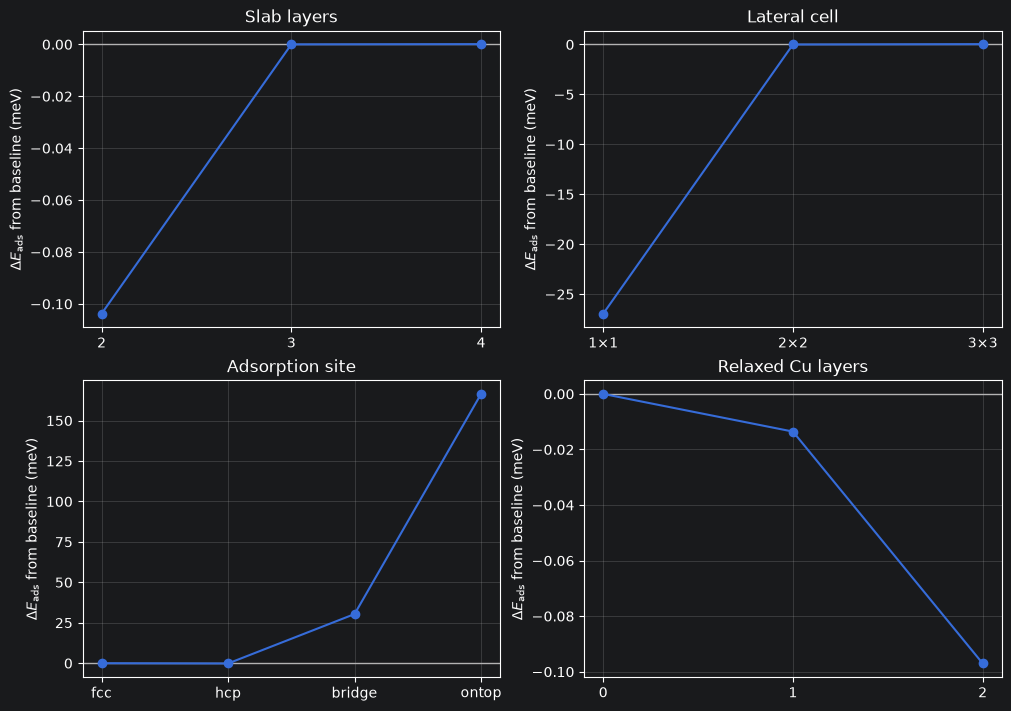

       Slab layers      2: E_ads = -4.6157 eV, height = 1.561 Å
       Slab layers      3: E_ads = -4.6156 eV, height = 1.561 Å
       Slab layers      4: E_ads = -4.6156 eV, height = 1.561 Å
      Lateral cell    1×1: E_ads = -4.6425 eV, height = 1.587 Å
      Lateral cell    2×2: E_ads = -4.6156 eV, height = 1.561 Å
      Lateral cell    3×3: E_ads = -4.6155 eV, height = 1.561 Å
   Adsorption site    fcc: E_ads = -4.6156 eV, height = 1.561 Å
   Adsorption site    hcp: E_ads = -4.6157 eV, height = 1.561 Å
   Adsorption site bridge: E_ads = -4.5852 eV, height = 1.609 Å
   Adsorption site  ontop: E_ads = -4.4491 eV, height = 1.843 Å
 Relaxed Cu layers      0: E_ads = -4.6156 eV, height = 1.561 Å
 Relaxed Cu layers      1: E_ads = -4.6156 eV, height = 1.557 Å
 Relaxed Cu layers      2: E_ads = -4.6157 eV, height = 1.557 Å


In [16]:
convergence_fmax = 0.01  # eV/Å
representative_surface = 'Cu'
representative_adsorbate = 'O'

with connect(path_to_bulk_db) as bulk_db:
    cu_bulk_row = next(bulk_db.select('Cu'))
cu_lattice_constant = 2 * cu_bulk_row.cell[0, 1]

isolated_adsorbate = Atoms(representative_adsorbate)
isolated_adsorbate.calc = EMT()
isolated_adsorbate_energy = isolated_adsorbate.get_potential_energy()
clean_energy_cache = {}
case_cache = {}


def relax_emt_structure(atoms, relaxed_substrate_layers):
    """Relax adsorbate and selected substrate layers with EMT."""
    fixed_indices = [
        atom.index
        for atom in atoms
        if atom.tag > relaxed_substrate_layers
    ]
    if fixed_indices:
        atoms.set_constraint(FixAtoms(indices=fixed_indices))

    atoms.calc = EMT()
    optimizer = BFGS(atoms, logfile=None)
    converged = optimizer.run(fmax=convergence_fmax, steps=300)
    if not converged:
        raise RuntimeError('Representative EMT relaxation did not converge.')
    return atoms


def evaluate_convergence_case(
    lateral_size=(2, 2),
    layers=3,
    site='fcc',
    relaxed_substrate_layers=0,
):
    """Return a matched Cu–O adsorption-energy calculation."""
    case_key = (lateral_size, layers, site, relaxed_substrate_layers)
    if case_key in case_cache:
        return case_cache[case_key]

    clean_key = (lateral_size, layers, relaxed_substrate_layers)
    if clean_key not in clean_energy_cache:
        clean_slab = fcc111(
            representative_surface,
            (*lateral_size, layers),
            a=cu_lattice_constant,
        )
        clean_slab = relax_emt_structure(
            clean_slab, relaxed_substrate_layers
        )
        clean_energy_cache[clean_key] = clean_slab.get_potential_energy()

    adsorbed_slab = fcc111(
        representative_surface,
        (*lateral_size, layers),
        a=cu_lattice_constant,
    )
    add_adsorbate(
        adsorbed_slab,
        representative_adsorbate,
        height=1.0,
        position=site,
    )
    adsorbed_slab = relax_emt_structure(
        adsorbed_slab, relaxed_substrate_layers
    )

    combined_energy = adsorbed_slab.get_potential_energy()
    adsorption_energy = (
        combined_energy
        - clean_energy_cache[clean_key]
        - isolated_adsorbate_energy
    )
    top_layer_z = adsorbed_slab.positions[
        adsorbed_slab.get_tags() == 1, 2
    ].mean()
    result = {
        'atoms': adsorbed_slab,
        'lateral_size': lateral_size,
        'layers': layers,
        'site': site,
        'relaxed_substrate_layers': relaxed_substrate_layers,
        'adsorption_energy_eV': adsorption_energy,
        'height_A': adsorbed_slab[-1].z - top_layer_z,
    }
    case_cache[case_key] = result
    return result


baseline_case = {
    'lateral_size': (2, 2),
    'layers': 3,
    'site': 'fcc',
    'relaxed_substrate_layers': 0,
}
convergence_sweeps = {
    'Slab layers': [
        ('2', {'layers': 2}),
        ('3', {'layers': 3}),
        ('4', {'layers': 4}),
    ],
    'Lateral cell': [
        ('1×1', {'lateral_size': (1, 1)}),
        ('2×2', {'lateral_size': (2, 2)}),
        ('3×3', {'lateral_size': (3, 3)}),
    ],
    'Adsorption site': [
        ('fcc', {'site': 'fcc'}),
        ('hcp', {'site': 'hcp'}),
        ('bridge', {'site': 'bridge'}),
        ('ontop', {'site': 'ontop'}),
    ],
    'Relaxed Cu layers': [
        ('0', {'relaxed_substrate_layers': 0}),
        ('1', {'relaxed_substrate_layers': 1}),
        ('2', {'relaxed_substrate_layers': 2}),
    ],
}

convergence_records = []
for study, cases in convergence_sweeps.items():
    for setting, override in cases:
        parameters = {**baseline_case, **override}
        result = evaluate_convergence_case(**parameters)
        convergence_records.append(
            {**result, 'study': study, 'setting': setting}
        )

path_to_convergence_db = output_dir / 'convergence.db'
path_to_convergence_db.unlink(missing_ok=True)
with connect(path_to_convergence_db) as convergence_db:
    convergence_db.metadata = {
        **environment_metadata,
        'settings': {
            'workflow': 'representative Cu-O EMT sensitivity study',
            'baseline': {
                'lateral_size': [2, 2],
                'layers': 3,
                'site': 'fcc',
                'relaxed_substrate_layers': 0,
            },
            'fmax_eV_per_A': convergence_fmax,
            'adsorbate_reference': 'isolated O atom',
        },
    }
    for record in convergence_records:
        size_x, size_y = record['lateral_size']
        convergence_db.write(
            record['atoms'],
            study=record['study'],
            setting_label=(
                f"{record['study']}={record['setting']}"
            ),
            surf=representative_surface,
            ads=representative_adsorbate,
            layers=record['layers'],
            size_x=size_x,
            size_y=size_y,
            site=record['site'],
            relaxed_layers=record['relaxed_substrate_layers'],
            ea=record['adsorption_energy_eV'],
            height=record['height_A'],
        )

reference_settings = {
    'Slab layers': '3',
    'Lateral cell': '2×2',
    'Adsorption site': 'fcc',
    'Relaxed Cu layers': '0',
}
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
for ax, (study, cases) in zip(axes.flat, convergence_sweeps.items()):
    study_records = [
        record
        for record in convergence_records
        if record['study'] == study
    ]
    positions = np.arange(len(study_records))
    energies = [
        record['adsorption_energy_eV'] for record in study_records
    ]
    labels = [record['setting'] for record in study_records]
    reference_energy = next(
        record['adsorption_energy_eV']
        for record in study_records
        if record['setting'] == reference_settings[study]
    )
    relative_energies_meV = [
        1000 * (energy - reference_energy) for energy in energies
    ]
    ax.axhline(0.0, color='0.7', linewidth=1)
    ax.plot(positions, relative_energies_meV, 'o-')
    ax.set_xticks(positions, labels)
    ax.set_title(study)
    ax.set_ylabel(r'$\Delta E_{\mathrm{ads}}$ from baseline (meV)')
    ax.grid(alpha=0.3)
plt.show()

for record in convergence_records:
    print(
        f"{record['study']:>18} {record['setting']:>6}: "
        f"E_ads = {record['adsorption_energy_eV']:+.4f} eV, "
        f"height = {record['height_A']:.3f} Å"
    )

### Interpreting the representative EMT sweeps

For the $(2 \times 2)$ Cu–O model, changing from two to four slab layers shifts $E_{\mathrm{ads}}$ by only about $+0.00010$ eV. Increasing the lateral cell from $(1 \times 1)$ to $(2 \times 2)$ changes the value by $+0.02695$ eV, whereas the $(2 \times 2)$ to $(3 \times 3)$ change is only $+0.00003$ eV. The first difference is therefore mainly a coverage or lateral-interaction effect in this model.

FCC and HCP hollow sites differ by about $-0.00016$ eV, while bridge and ontop are higher than FCC by about $0.03038$ and $0.16648$ eV, respectively. Relaxing two Cu layers changes the frozen-substrate energy by about $-0.00010$ eV and lowers the adsorption height by roughly $0.004$ Å. These numerical comparisons are useful for choosing the next calculations, but their small size does not establish transferable chemical accuracy outside EMT.

## Opt-in higher-accuracy validation with GPAW

EMT is appropriate for demonstrating the workflow, but its adsorption-energy ordering should not be interpreted as a quantitative chemical trend. The cell below provides a deliberately disabled GPAW/PBE plane-wave calculation for one converged Cu–O model. It relaxes the adsorbed and clean slabs with identical numerical settings, evaluates a spin-polarized isolated O atom, and stores the three calculations plus full database-level settings in `gpaw_validation.db`.

The default `RUN_GPAW_VALIDATION = False` prevents an expensive calculation from starting during a normal tutorial run. Before enabling it, converge the plane-wave cutoff, $k$-point mesh, vacuum, slab thickness, lateral size, force tolerance, smearing, magnetic state, and reference convention. A single Cu–O result validates the workflow only; quantitative trends require applying the converged protocol consistently across the compared systems.

In [17]:
import importlib.util

RUN_GPAW_VALIDATION = False
gpaw_available = importlib.util.find_spec('gpaw') is not None

if not RUN_GPAW_VALIDATION:
    availability = 'available' if gpaw_available else 'not installed'
    print(
        f'GPAW is {availability}; validation is disabled. '
        'Set RUN_GPAW_VALIDATION = True only after choosing converged settings.'
    )
elif not gpaw_available:
    raise ModuleNotFoundError(
        'GPAW is required for the optional higher-accuracy validation.'
    )
else:
    import gpaw
    from gpaw import FermiDirac, GPAW, PW

    gpaw_cutoff_eV = 450
    gpaw_kpoints = (4, 4, 1)
    gpaw_vacuum_A = 8.0
    gpaw_fmax = 0.05  # eV/Å

    def make_gpaw_slab(adsorbed):
        """Build a Cu(111) slab with its bottom two layers fixed."""
        slab = fcc111('Cu', (2, 2, 3), a=cu_lattice_constant)
        if adsorbed:
            add_adsorbate(slab, 'O', height=1.6, position='fcc')
        slab.center(vacuum=gpaw_vacuum_A, axis=2)
        fixed_indices = [atom.index for atom in slab if atom.tag > 1]
        slab.set_constraint(FixAtoms(indices=fixed_indices))
        return slab

    def relax_with_gpaw(atoms, label):
        """Relax one periodic slab using the shared GPAW settings."""
        atoms.calc = GPAW(
            mode=PW(gpaw_cutoff_eV),
            xc='PBE',
            kpts={'size': gpaw_kpoints, 'gamma': True},
            occupations=FermiDirac(0.1),
            txt=output_dir / f'gpaw_{label}.txt',
        )
        optimizer = BFGS(
            atoms,
            trajectory=output_dir / f'gpaw_{label}.traj',
            logfile=output_dir / f'gpaw_{label}.log',
        )
        if not optimizer.run(fmax=gpaw_fmax, steps=200):
            raise RuntimeError(f'GPAW relaxation did not converge: {label}')
        return atoms

    gpaw_adsorbed = relax_with_gpaw(
        make_gpaw_slab(True), 'CuO_adsorbed'
    )
    gpaw_clean = relax_with_gpaw(make_gpaw_slab(False), 'Cu_clean')

    gpaw_oxygen = Atoms(
        'O', magmoms=[2.0], cell=(10.0, 10.0, 10.0), pbc=False
    )
    gpaw_oxygen.center()
    gpaw_oxygen.calc = GPAW(
        mode=PW(gpaw_cutoff_eV),
        xc='PBE',
        kpts=(1, 1, 1),
        spinpol=True,
        hund=True,
        txt=output_dir / 'gpaw_O_atom.txt',
    )
    gpaw_oxygen_energy = gpaw_oxygen.get_potential_energy()
    gpaw_adsorption_energy = (
        gpaw_adsorbed.get_potential_energy()
        - gpaw_clean.get_potential_energy()
        - gpaw_oxygen_energy
    )

    gpaw_db_path = output_dir / 'gpaw_validation.db'
    gpaw_db_path.unlink(missing_ok=True)
    with connect(gpaw_db_path) as gpaw_db:
        gpaw_db.metadata = {
            'schema_version': 1,
            'generated_utc': datetime.now(timezone.utc).isoformat(),
            'ase_version': ase.__version__,
            'gpaw_version': gpaw.__version__,
            'settings': {
                'xc': 'PBE',
                'plane_wave_cutoff_eV': gpaw_cutoff_eV,
                'slab_kpoints': list(gpaw_kpoints),
                'smearing_eV': 0.1,
                'vacuum_A': gpaw_vacuum_A,
                'fmax_eV_per_A': gpaw_fmax,
                'slab': 'Cu(111), 2x2, 3 layers, bottom 2 fixed',
                'adsorption_site': 'fcc',
                'adsorbate_reference': (
                    'spin-polarized isolated O atom'
                ),
            },
        }
        gpaw_db.write(gpaw_adsorbed, role='adsorbed')
        gpaw_db.write(gpaw_clean, role='clean')
        gpaw_db.write(gpaw_oxygen, role='isolated_atom')

    print(f'GPAW/PBE adsorption energy: {gpaw_adsorption_energy:+.4f} eV')

GPAW is available; validation is disabled. Set RUN_GPAW_VALIDATION = True only after choosing converged settings.


## Takeaways and remaining convergence work

The database now supports the complete analysis cycle: validate the intended parameter grid, query all structures by scientific keys, visualize the full energy table, export selected scalar results, preserve calculation provenance, and store additional convergence calculations in their own database.

- The completeness audit must pass before the heatmaps or CSV are produced.
- `adsorption_summary.csv` is a portable summary; `ads.db` remains the structure-bearing source of truth.
- Database-level metadata records settings shared by a workflow, while row keys record parameters that vary between calculations.
- The Cu–O sweeps expose layer, coverage, site, and substrate-relaxation sensitivity within EMT and should guide a more focused convergence study.
- Quantitative chemical trends still require converged higher-accuracy calculations across every compared system. The GPAW cell is opt-in and should not be enabled with untested numerical settings.
- POV-Ray remains optional because `plot_atoms` provides a dependency-light structural check.